In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd

df = pd.read_csv("C:/Users/Theertha/OneDrive/Desktop/project 3/application_train new.csv")
print(df.shape)
df.head()

C:\Users\Theertha\AppData\Local\Temp\ipykernel_13044\313042899.py:3: DtypeWarning: Columns (0: NUM_INSTALMENT) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:/Users/Theertha/OneDrive/Desktop/project 3/application_train new.csv")


(307511, 123)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nTarget Distribution:\n")
print(df['TARGET'].value_counts())

print("\nTarget Percentage:\n")
print(df['TARGET'].value_counts(normalize=True))

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 123 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(1), str(16)
memory usage: 327.6+ MB
None

Missing Values:

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 123, dtype: int64

Target Distribution:

TARGET
0    282686
1     24825
Name: count, dtype: int64

Target Percentage:

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [4]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False).head(20)

COMMONAREA_MEDI             214865
COMMONAREA_MODE             214865
COMMONAREA_AVG              214865
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_MODE       210199
FLOORSMIN_MEDI              208642
FLOORSMIN_MODE              208642
FLOORSMIN_AVG               208642
YEARS_BUILD_MODE            204488
YEARS_BUILD_MEDI            204488
YEARS_BUILD_AVG             204488
OWN_CAR_AGE                 202929
LANDAREA_AVG                182590
LANDAREA_MEDI               182590
LANDAREA_MODE               182590
dtype: int64

In [5]:
threshold = len(df) * 0.5

df = df.dropna(thresh=threshold, axis=1)

print("New Shape:", df.shape)

New Shape: (307511, 82)


In [6]:
# Fill numeric columns with median
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns with mode
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Remaining Missing Values:", df.isnull().sum().sum())

C:\Users\Theertha\AppData\Local\Temp\ipykernel_13044\17889478.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


Remaining Missing Values: 0


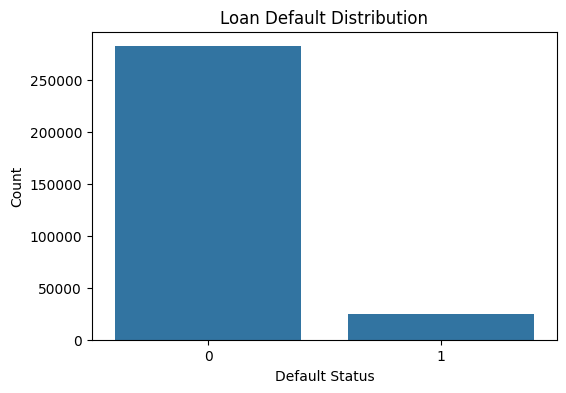

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(x='TARGET', data=df)

plt.title("Loan Default Distribution")
plt.xlabel("Default Status")
plt.ylabel("Count")

plt.show()

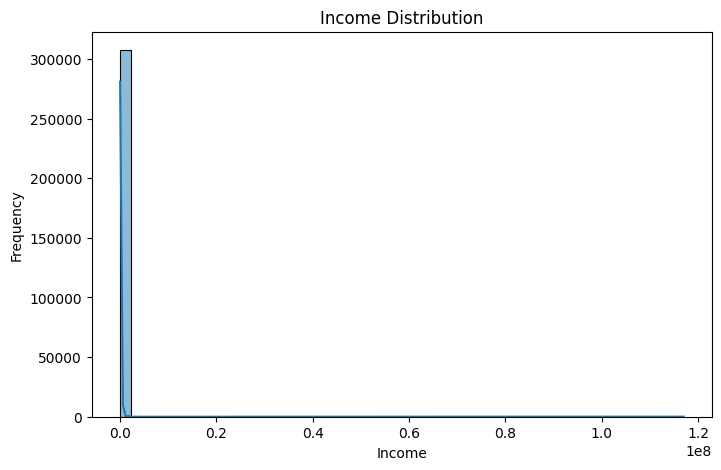

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df['AMT_INCOME_TOTAL'], bins=50, kde=True)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")

plt.show()

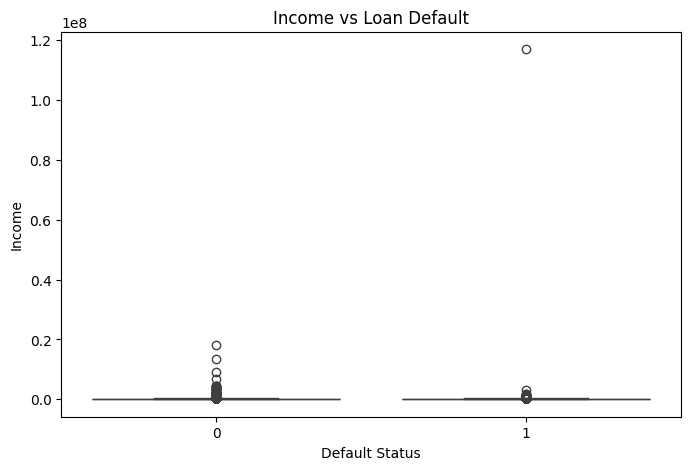

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=df)

plt.title("Income vs Loan Default")
plt.xlabel("Default Status")
plt.ylabel("Income")

plt.show()

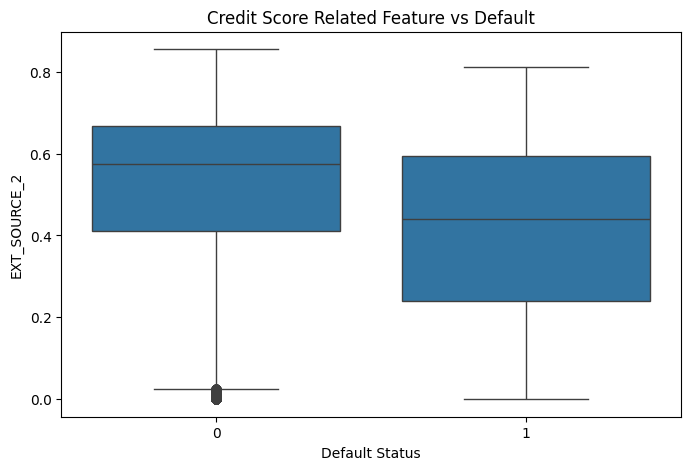

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(x='TARGET', y='EXT_SOURCE_2', data=df)

plt.title("Credit Score Related Feature vs Default")
plt.xlabel("Default Status")
plt.ylabel("EXT_SOURCE_2")

plt.show()

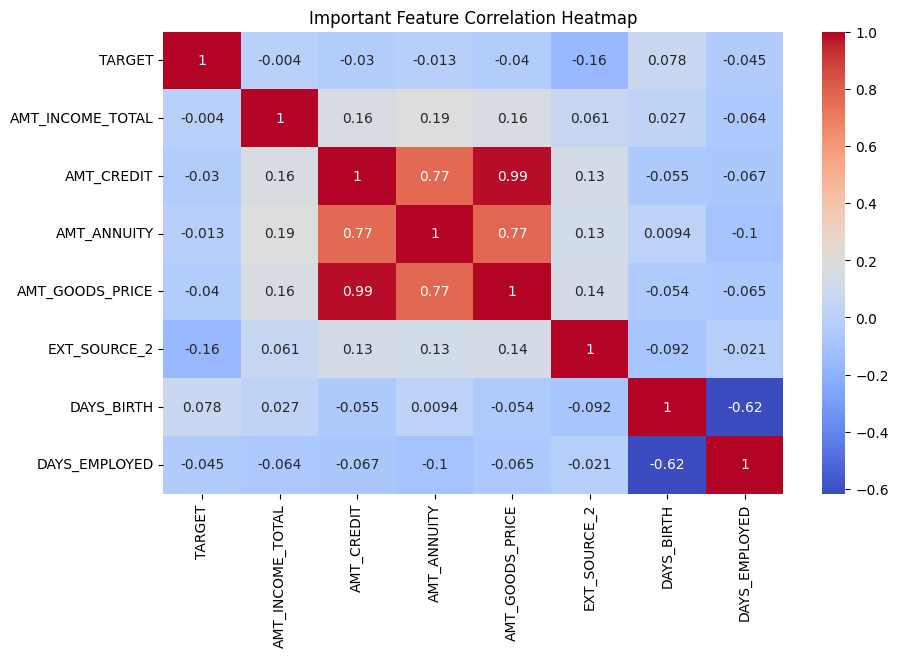

In [11]:
important_features = [
    'TARGET',
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'EXT_SOURCE_2',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED'
]

plt.figure(figsize=(10,6))

corr_matrix = df[important_features].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Important Feature Correlation Heatmap")

plt.show()

In [12]:
df['LOAN_TO_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

df['LOAN_TO_INCOME_RATIO'].head()

0    2.007889
1    4.790750
2    2.000000
3    2.316167
4    4.222222
Name: LOAN_TO_INCOME_RATIO, dtype: float64

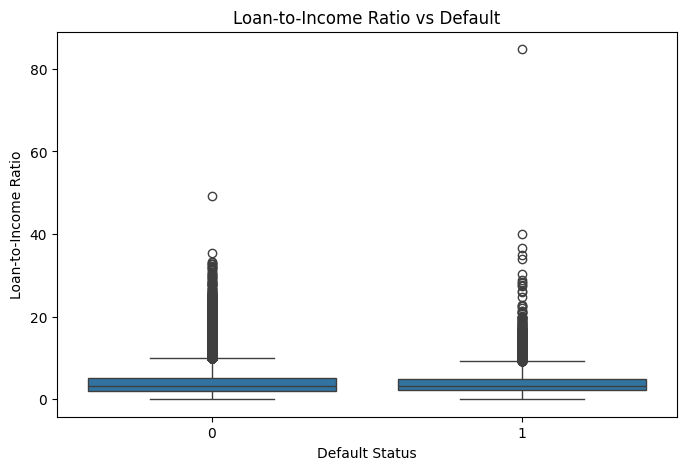

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(x='TARGET', y='LOAN_TO_INCOME_RATIO', data=df)

plt.title("Loan-to-Income Ratio vs Default")
plt.xlabel("Default Status")
plt.ylabel("Loan-to-Income Ratio")

plt.show()

In [15]:
selected_features = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'EXT_SOURCE_2',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'LOAN_TO_INCOME_RATIO'
]

X = df[selected_features]

y = df['TARGET']

print(X.shape)
print(y.shape)

(307511, 8)
(307511,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (246008, 8)
Testing Shape: (61503, 8)


In [17]:
train_df = X_train.copy()
train_df['TARGET'] = y_train

test_df = X_test.copy()
test_df['TARGET'] = y_test

train_df.to_csv("train_data.csv", index=False)
test_df.to_csv("test_data.csv", index=False)

print("Train and test CSV files created successfully.")

Train and test CSV files created successfully.


In [21]:
!pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalan


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Theertha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [22]:
from imblearn.over_sampling import SMOTE

In [23]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE train size : {X_train_sm.shape}")
print(f"After SMOTE class balance:\n{pd.Series(y_train_sm).value_counts()}")


After SMOTE train size : (452296, 8)
After SMOTE class balance:
TARGET
0    226148
1    226148
Name: count, dtype: int64


In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)
print("Scaling done ✓")

Scaling done ✓


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    C=0.1,
    solver='lbfgs',
    random_state=42
)

lr.fit(X_train_sc, y_train_sm)

y_pred_lr = lr.predict(X_test_sc)

y_proba_lr = lr.predict_proba(X_test_sc)[:, 1]

print("Logistic Regression trained ✓")

print(classification_report(
    y_test,
    y_pred_lr,
    target_names=['No Default', 'Default']
))

Logistic Regression trained ✓
              precision    recall  f1-score   support

  No Default       0.95      0.67      0.78     56538
     Default       0.14      0.59      0.22      4965

    accuracy                           0.66     61503
   macro avg       0.54      0.63      0.50     61503
weighted avg       0.88      0.66      0.74     61503



In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=50,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train_sm, y_train_sm)

y_pred_rf = rf.predict(X_test)

y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest trained ✓")

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=['No Default', 'Default']
))

Random Forest trained ✓
              precision    recall  f1-score   support

  No Default       0.95      0.67      0.79     56538
     Default       0.14      0.59      0.22      4965

    accuracy                           0.66     61503
   macro avg       0.54      0.63      0.50     61503
weighted avg       0.88      0.66      0.74     61503



In [30]:
!pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 1.7 MB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.5 MB 2.0 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 1.9 MB/s  0:00:00



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Theertha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [31]:
import lightgbm as lgb
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count
print(f"scale_pos_weight = {spw:.2f}")

lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=8,
    min_child_samples=50,
    scale_pos_weight=spw,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    n_jobs=-1,
    random_state=42
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

y_pred_lgbm  = lgbm.predict(X_test)
y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]

print("\nLightGBM trained ✓")
print(classification_report(y_test, y_pred_lgbm, target_names=['No Default', 'Default']))

scale_pos_weight = 11.39
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009803 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1933
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482

LightGBM trained ✓
              precision    recall  f1-score   support

  No Default       0.92      1.00      0.96     56538
     Default       0.00      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.46      0.50      0.48     61503
weighted avg       0.85      0.92      0.88     61503



C:\Users\Theertha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Theertha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Theertha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metr

## Confusion Matrix Visualization

Confusion matrices were generated for all trained machine learning models to evaluate their classification performance. A confusion matrix provides a detailed summary of prediction results by comparing actual and predicted class labels.

The matrix displays:
- True Positives (correctly predicted defaults)
- True Negatives (correctly predicted non-defaults)
- False Positives
- False Negatives

This visualization helps in understanding model effectiveness, identifying classification errors, and comparing the performance of different models such as Logistic Regression, Random Forest, and LightGBM.

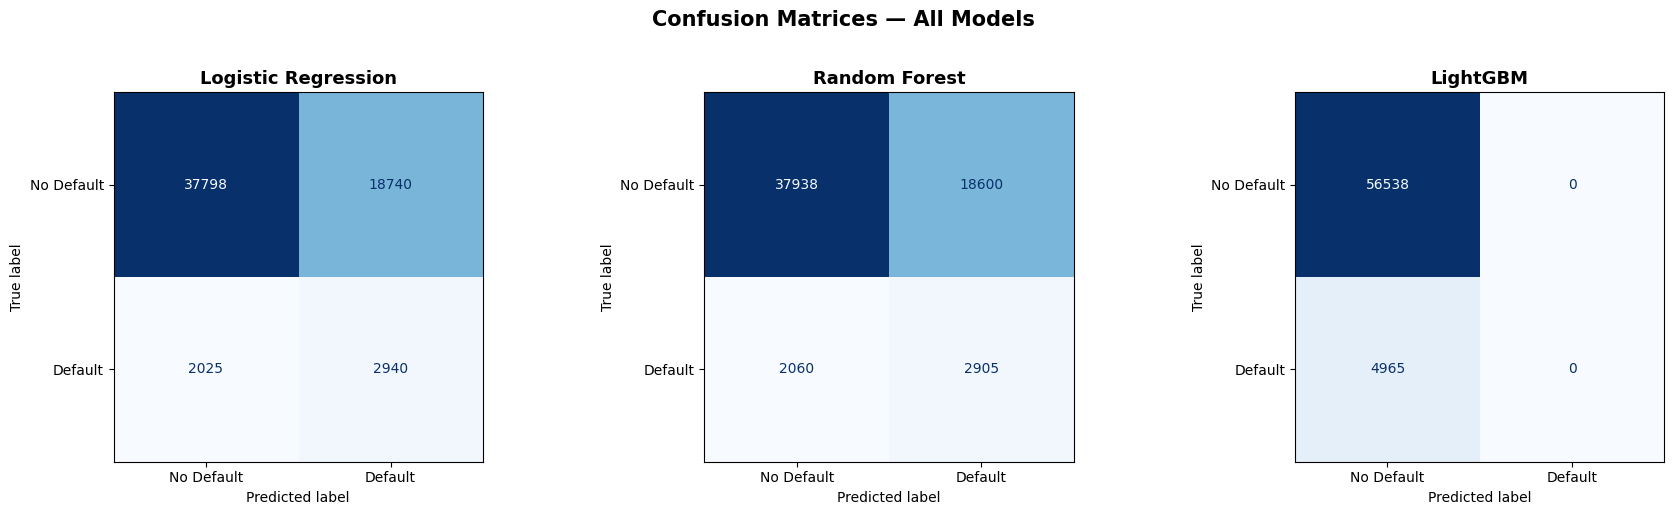

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_info = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest',        y_pred_rf),
    ('LightGBM',             y_pred_lgbm)
]

for ax, (name, y_pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [34]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

## ROC Curve Analysis

The Receiver Operating Characteristic (ROC) curve is used to evaluate the classification performance of the machine learning models across different threshold values.

The ROC curve compares:
- True Positive Rate (Recall)
- False Positive Rate

The Area Under the Curve (AUC) measures the model’s ability to distinguish between default and non-default cases.

The following models are compared:
- Logistic Regression
- Random Forest
- LightGBM

A higher ROC-AUC value indicates better classification performance and stronger predictive capability.

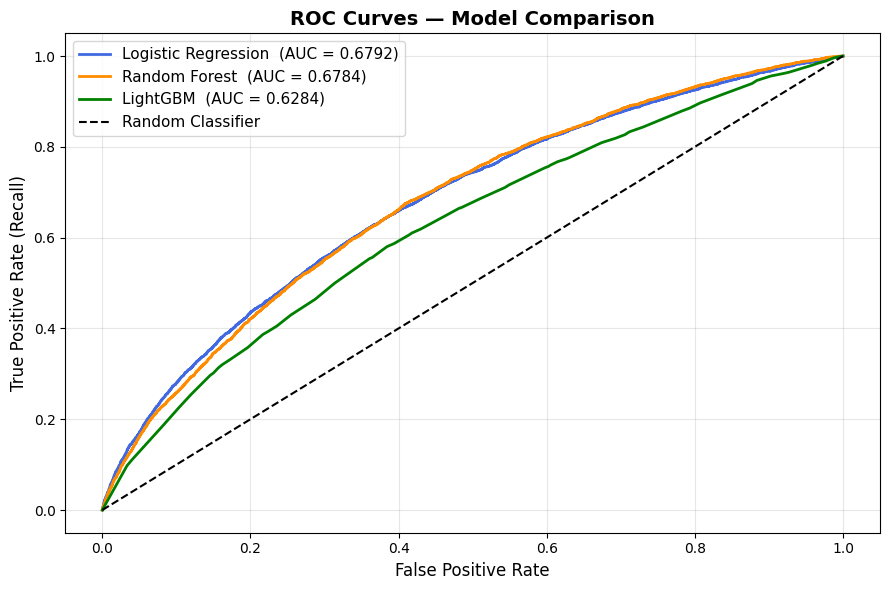

In [35]:
plt.figure(figsize=(9, 6))

proba_dict = {
    'Logistic Regression': y_proba_lr,
    'Random Forest':        y_proba_rf,
    'LightGBM':             y_proba_lgbm
}
colors = ['royalblue', 'darkorange', 'green']

for (name, proba), color in zip(proba_dict.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.4f})', color=color, lw=2)

plt.plot([0,1],[0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score
)

## Precision–Recall Curve Analysis

The Precision–Recall (PR) curve is used to evaluate the performance of classification models, especially for imbalanced datasets.

The PR curve illustrates the relationship between:
- Precision
- Recall

The following models are compared:
- Logistic Regression
- Random Forest
- LightGBM

A model with higher precision and recall values demonstrates better capability in identifying default cases while minimizing false predictions.

The baseline line represents the prevalence of the positive class in the dataset and serves as a reference for model performance comparison.

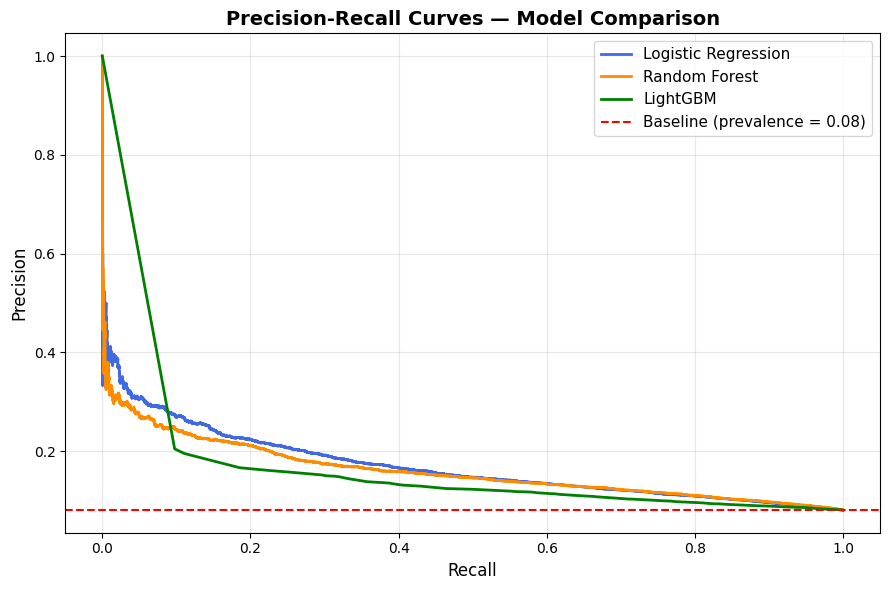

In [41]:
plt.figure(figsize=(9, 6))

for (name, proba), color in zip(proba_dict.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, proba)
    plt.plot(recall, precision, label=name, color=color, lw=2)

baseline = y_test.mean()
plt.axhline(y=baseline, color='red', linestyle='--', label=f'Baseline (prevalence = {baseline:.2f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves — Model Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Model Performance Comparison

The performance of the machine learning models is evaluated using multiple classification metrics to determine their predictive capability and overall effectiveness.

The following models are compared:
- Logistic Regression
- Random Forest
- LightGBM

The evaluation metrics include:
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

These metrics help analyze the models in terms of classification accuracy, ability to detect default cases, balance between precision and recall, and overall discriminative performance.

The best-performing models are identified based on:
- Highest Recall
- Highest ROC-AUC Score

In [42]:
from sklearn.metrics import accuracy_score, precision_score

results = []
for name, y_pred, y_proba in [
    ('Logistic Regression', y_pred_lr,   y_proba_lr),
    ('Random Forest',        y_pred_rf,   y_proba_rf),
    ('LightGBM',             y_pred_lgbm, y_proba_lgbm)
]:
    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test,  y_pred),  4),
        'Precision': round(precision_score(y_test, y_pred),  4),
        'Recall':    round(recall_score(y_test,    y_pred),   4),
        'F1-Score':  round(f1_score(y_test,        y_pred),   4),
        'ROC-AUC':   round(roc_auc_score(y_test,   y_proba),  4),
    })

results_df = pd.DataFrame(results).set_index('Model')
print('\n===== Model Comparison Table =====')
print(results_df.to_string())

# ── Highlight best recall ─────────────────────────────────────────────────────
best_recall_model = results_df['Recall'].idxmax()
best_auc_model    = results_df['ROC-AUC'].idxmax()
print(f"\n→ Best Recall  : {best_recall_model}")
print(f"→ Best ROC-AUC : {best_auc_model}")


===== Model Comparison Table =====
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.6624     0.1356  0.5921    0.2207   0.6792
Random Forest          0.6641     0.1351  0.5851    0.2195   0.6784
LightGBM               0.9193     0.0000  0.0000    0.0000   0.6284

→ Best Recall  : Logistic Regression
→ Best ROC-AUC : Logistic Regression


C:\Users\Theertha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [44]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

## 5-Fold Cross-Validation

Stratified 5-Fold Cross-Validation is performed on the LightGBM model to evaluate its stability and generalization performance.

The dataset is divided into five folds while preserving class distribution.  
For each fold, the ROC-AUC score is calculated and the mean and standard deviation are analyzed.

This helps assess the consistency and reliability of the model across different data splits.

LightGBM 5-Fold CV ROC-AUC Scores: [0.6986 0.7014 0.6944 0.7069 0.6991]
Mean  : 0.7001
Std   : 0.0041


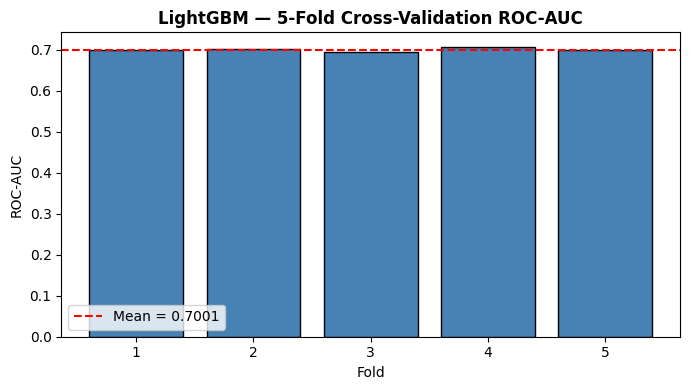

In [45]:
# ── 5-Fold Stratified CV on LightGBM ─────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    lgbm, X, y,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"LightGBM 5-Fold CV ROC-AUC Scores: {cv_scores.round(4)}")
print(f"Mean  : {cv_scores.mean():.4f}")
print(f"Std   : {cv_scores.std():.4f}")

plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='black')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('ROC-AUC')
plt.title('LightGBM — 5-Fold Cross-Validation ROC-AUC', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## Threshold Optimization

Threshold optimization is performed on the LightGBM model to improve classification performance for the default class.

Using the Precision–Recall curve, different probability thresholds are evaluated.  
The optimal threshold is selected based on:
- Recall ≥ 0.70
- Highest possible Precision

The selected threshold is then applied to generate final predictions and evaluate the classification performance using a classification report.

In [46]:
# ── Find threshold that maximises Recall with acceptable Precision ─────────────
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_test, y_proba_lgbm)

# Target: recall >= 0.70, then pick highest precision
candidates = pd.DataFrame({
    'Threshold': thresholds_arr,
    'Precision': precision_arr[:-1],
    'Recall':    recall_arr[:-1]
})

good_thresholds = candidates[candidates['Recall'] >= 0.70]
best_row = good_thresholds.loc[good_thresholds['Precision'].idxmax()]

print(f"Optimal Threshold : {best_row['Threshold']:.4f}")
print(f"At this threshold → Recall: {best_row['Recall']:.4f}, Precision: {best_row['Precision']:.4f}")

# ── Apply optimal threshold ───────────────────────────────────────────────────
THRESHOLD       = best_row['Threshold']
y_pred_opt      = (y_proba_lgbm >= THRESHOLD).astype(int)

print("\nClassification Report at Optimal Threshold:")
print(classification_report(y_test, y_pred_opt, target_names=['No Default', 'Default']))

Optimal Threshold : 0.1008
At this threshold → Recall: 0.7106, Precision: 0.1029

Classification Report at Optimal Threshold:
              precision    recall  f1-score   support

  No Default       0.95      0.46      0.62     56538
     Default       0.10      0.71      0.18      4965

    accuracy                           0.48     61503
   macro avg       0.53      0.58      0.40     61503
weighted avg       0.88      0.48      0.58     61503

